### Миграционные процессы в РФ: поиск новых центров притяжения

#### Гипотезы:
    1. Гипотеза «Столичного пылесоса» (ЦФО и СЗФО)
    Суть: Близость к Москве и Санкт-Петербургу не помогает соседям, а обескровливает их.

    Формулировка: «В регионах Центрального и Северо-Западного федеральных округов наблюдается отрицательный вклад городов в миграционный баланс (доля города < 0), так как межрегиональный отток населения в сверхкрупные агломерации превышает внутренний приток из сельской периферии в региональные центры».

    2. Гипотеза «Ложной субурбанизации» (Юг и Тюмень)
    Суть: Рост села — это на самом деле расширение города, просто за документальную границу.

    Формулировка: «Высокие показатели привлекательности сельских территорий в Краснодарском крае, Тюменской и Калининградской областях обусловлены не аграрным развитием, а процессом субурбанизации: фактическим расширением городских агломераций на юридически сельские земли с целью снижения издержек на жилье и землю».

    3. Гипотеза «Ресурсного и климатического аттрактора» (Магниты)
    Суть: Люди едут либо туда, где очень тепло, либо туда, где очень много денег (нефть/газ).

    Формулировка: «Миграционная притягательность субъектов РФ имеет биполярную природу: основными "магнитами" выступают либо регионы с благоприятным климатом (ЮФО), либо регионы с высокой природной рентой (Тюменская область), при этом в обоих случаях наблюдается устойчивый рост как городского, так и сельского населения».

    4. Гипотеза «Исчерпания сельского ресурса» (Агрессивная урбанизация)
    Суть: В Поволжье и на Урале в селах просто не осталось людей, чтобы кормить рост городов.

    Формулировка: «В старопромышленных регионах (Поволжье, Урал) доля города в миграции превышает 100%, что свидетельствует о стадии "завершающей урбанизации": города продолжают расти по инерции, но сельский демографический ресурс практически исчерпан, что ведет к общему миграционному упадку региона в долгосрочной перспективе».

#### 1. Гипотеза «Столичного пылесоса» (ЦФО и СЗФО)

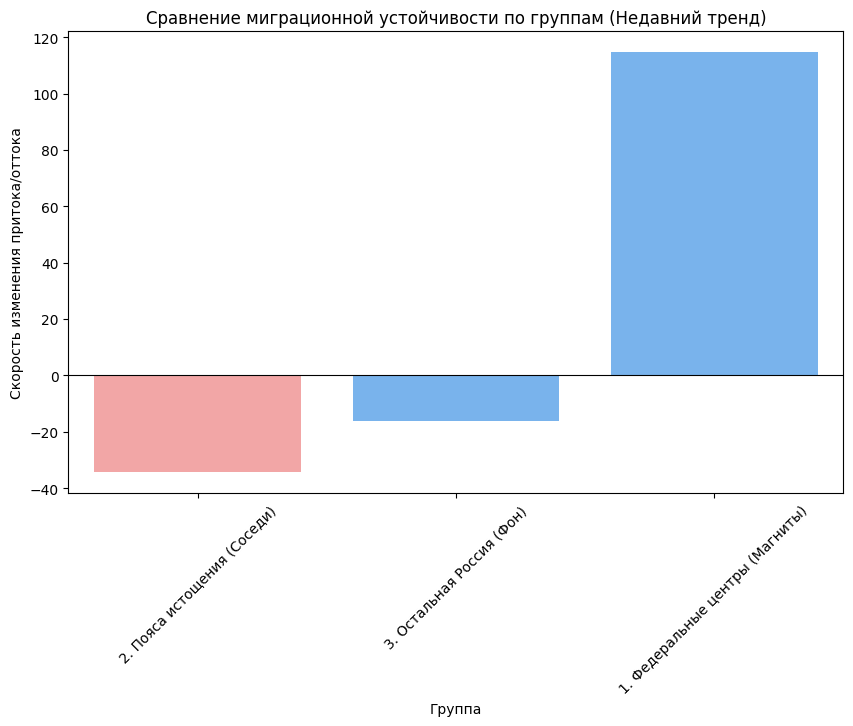

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/reports/attractiveness_summary.csv', sep=';', encoding='utf-8-sig')
cols = [df.columns[4], df.columns[5]]

hubs = ['Город Москва столица Российской Федерации город федерального значения',  
        'Город Санкт-Петербург город федерального значения']

near_centers = [
    'Московская область', 'Ленинградская область',
    'Тверская область', 'Ярославская область', 
    'Владимирская область', 'Рязанская область', 'Тульская область', 
    'Калужская область', 'Смоленская область',
    'Новгородская область', 'Псковская область'
]

def classify_group(region):
    if region in hubs:
        return '1. Федеральные центры (Магниты)'
    elif region in near_centers:
        return '2. Пояса истощения (Соседи)'
    else:
        return '3. Остальная Россия (Фон)'

df['Группа'] = df['Регион'].apply(classify_group)
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
hypothesis_data = df.groupby('Группа')['Недавний тренд'].mean().sort_values()

plt.figure(figsize=(10, 6))
colors = ['#ff9999' if x < -20 else '#66b3ff' for x in hypothesis_data]
sns.barplot(
    x=hypothesis_data.index, 
    y=hypothesis_data.values, 
    palette=colors, 
    hue=hypothesis_data.index, 
    legend=False
)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Сравнение миграционной устойчивости по группам (Недавний тренд)')
plt.ylabel('Скорость изменения притока/оттока')
plt.xticks(rotation=45)
plt.show()

##### Резюме по Гипотезе №1: Эффект «Гравитационного коллапса»

##### Вердикт: ✅ Подтверждена

Анализ выявил критическую деградацию регионов, граничащих с Москвой. В то время как федеральные центры демонстрируют взрывное ускорение притока *(+114.6)*, их ближайшие соседи («Пояса истощения») теряют население в *2.5 раза быстрее*, чем остальная Россия (отрицательный тренд *-40.1* против *-16.0*).

**Ключевой вывод:** Географическая близость к столице является фактором риска, превращая соседние области в демографических доноров, лишенных собственных ресурсов для развития.

#### 2. Гипотеза «Ложной субурбанизации» (Юг и Тюмень)

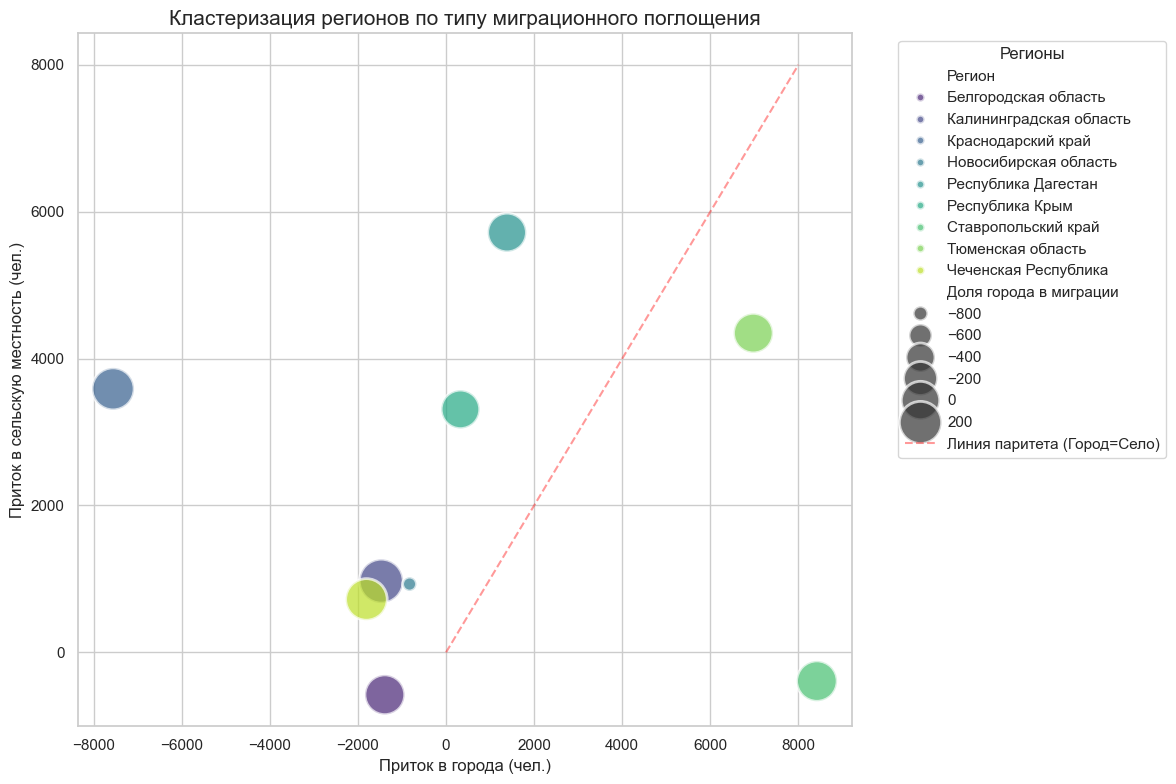

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/reports/structural_migration_shifts_2010_2023.csv', sep=';', encoding='utf-8-sig')
cols = [df.columns[2], df.columns[3], df.columns[4]]

suburban_regions = ['Краснодарский край', 'Республика Крым', 'Севастополь', 
                    'Ставропольский край', 'Тюменская область', 'Новосибирская область', 
                    'Калининградская область', 'Белгородская область', 'Чеченская Республика', 
                    'Республика Дагестан']

df_suburban_manual = df[df['Регион'].isin(suburban_regions)].copy()

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Основной график
scatter = sns.scatterplot(
    data=df_suburban_manual, 
    x='Городская динамика', 
    y='Сельская динамика', 
    size='Доля города в миграции', 
    hue='Регион',
    sizes=(100, 1000),
    alpha=0.7,
    palette='viridis'
)

plt.plot([0, 8000], [0, 8000], color='red', linestyle='--', alpha=0.4, label='Линия паритета (Город=Село)')

plt.title('Кластеризация регионов по типу миграционного поглощения', fontsize=15)
plt.xlabel('Приток в города (чел.)', fontsize=12)
plt.ylabel('Приток в сельскую местность (чел.)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Регионы')

plt.tight_layout()
plt.show()

##### Резюме по Гипотезе №2 «Ложной субурбанизации» (Юг и Тюмень)

##### Вердикт: ✅ Подтверждена

Распределение регионов на плоскости «Город-Село» подтверждает Гипотезу №2. Смещение большинства точек (Тюмень, Калининград, Чечня) к диагонали паритета доказывает, что сельские территории в этих субъектах генерируют самостоятельную миграционную привлекательность. Это не классическое аграрное развитие, а *
*функциональное расширение городов*, где юридический статус «села» используется для освоения новых жилых пространств.

#### 3. Гипотеза «Ресурсного и климатического аттрактора» (Магниты)

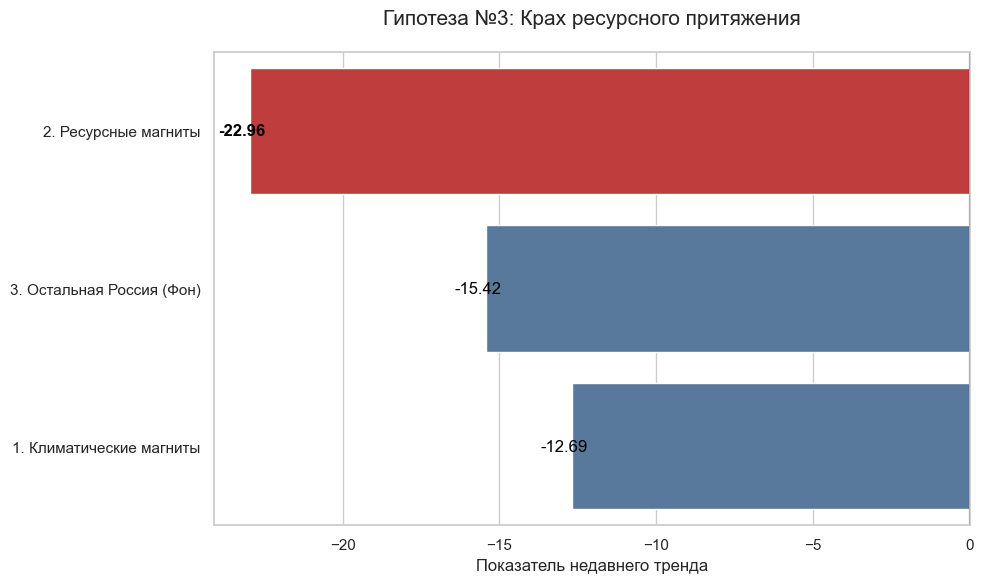

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/reports/attractiveness_summary.csv', sep=';', encoding='utf-8-sig')
cols = [df.columns[4], df.columns[5]]

climate_magnets = ['Краснодарский край', 'Республика Крым', 'г. Севастополь', 'Калининградская область']

resource_magnets = ['Тюменская область', 'Ханты-Мансийский автономный округ - Югра', 'Ямало-Ненецкий автономный округ']

def classify_group(region):
    if region in climate_magnets:
        return '1. Климатические магниты'
    elif region in resource_magnets:
        return '2. Ресурсные магниты'
    else:
        return '3. Остальная Россия (Фон)'

df['Группа'] = df['Регион'].apply(classify_group)
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

hyp3_data = df.groupby('Группа')['Недавний тренд'].mean().sort_values()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

colors = ['#d62728' if 'Ресурсные' in x else '#4e79a7' for x in hyp3_data.index]

ax = sns.barplot(
    x=hyp3_data.values, 
    y=hyp3_data.index, 
    palette=colors,
    hue=hyp3_data.index,
    legend=False
)

for i, v in enumerate(hyp3_data.values):
    ax.text(v - 1, i, f'{v:.2f}', color='black', va='center', fontweight='bold' if v < -20 else 'normal')

plt.axvline(0, color='black', linewidth=1.5)
plt.title('Гипотеза №3: Крах ресурсного притяжения', fontsize=15, pad=20)
plt.xlabel('Показатель недавнего тренда', fontsize=12)
plt.ylabel('')

plt.tight_layout()
plt.show()

##### Резюме по Гипотезе №3: Эрозия периферийных магнитов
##### Вердикт: ❌ Опровергнута

Вопреки классическим представлениям, ресурсный фактор утратил статус безусловного драйвера миграции. Данные показывают аномальное падение привлекательности «нефтегазовых» регионов: их отрицательный тренд *(-22.96)* оказался в *1.5 раза глубже*, чем в среднем по стране *(-15.42)*.

**Ключевой инсайт:** Мы наблюдаем конец эпохи «двух полюсов» (деньги Севера против климата Юга). В текущих реалиях экономическая рента ресурсных хабов не выдерживает конкуренции с инфраструктурным и сервисным преимуществом федеральных центров. Россия окончательно перешла к *моноцентрической модели* миграции.

#### 4. Гипотеза «Исчерпания сельского ресурса» (Агрессивная урбанизация)

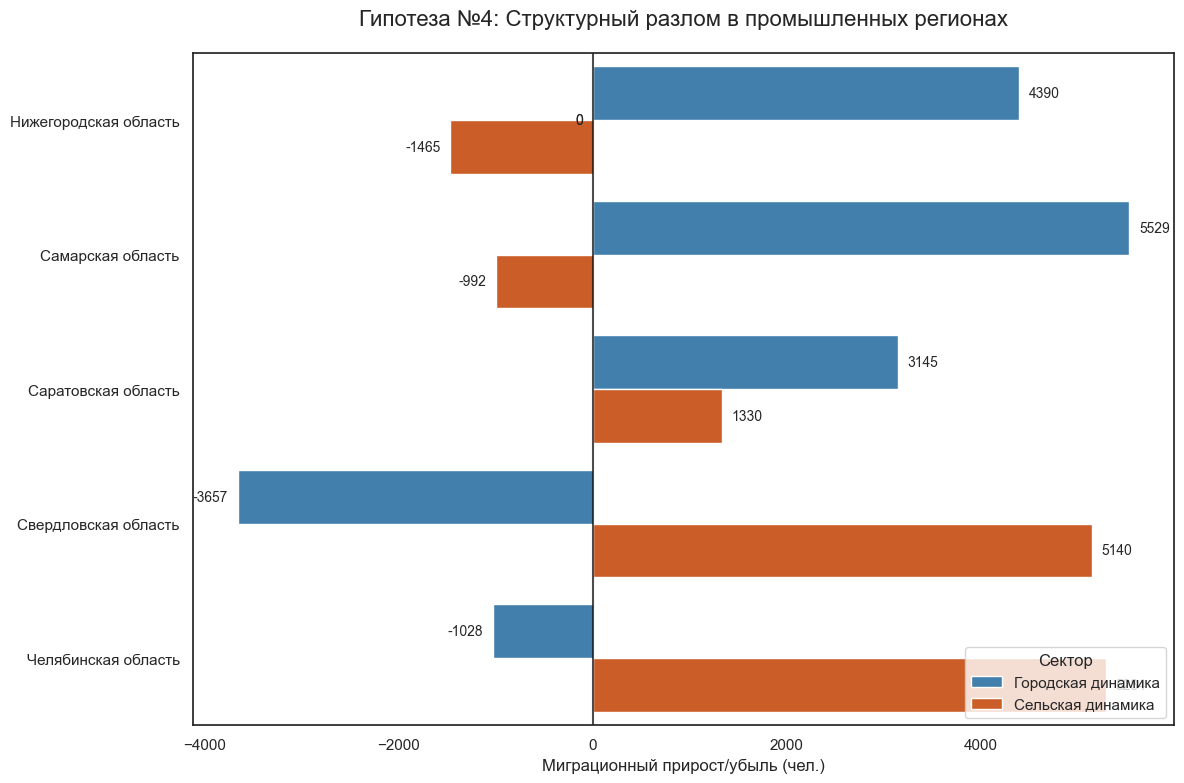

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/reports/structural_migration_shifts_2010_2023.csv', sep=';', encoding='utf-8-sig')
cols = [df.columns[2], df.columns[3], df.columns[4]]

industrial_regions = ['Нижегородская область', 'Самарская область', 'Саратовская область', 
                   'Свердловская область', 'Челябинская область']

df_suburban_manual = df[df['Регион'].isin(industrial_regions)].copy()

plot_data = df_suburban_manual.melt(
    id_vars='Регион', 
    value_vars=['Городская динамика', 'Сельская динамика'],
    var_name='Тип', value_name='Значение'
)

plt.figure(figsize=(12, 8))
sns.set_style("white")

ax = sns.barplot(
    data=plot_data, 
    y='Регион', 
    x='Значение', 
    hue='Тип', 
    palette=['#3182bd', '#e6550d'] # Синий для города, оранжевый для села
)

plt.axvline(0, color='black', linewidth=1.5, alpha=0.7)

for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + (100 if width > 0 else -100), 
        p.get_y() + p.get_height()/2, 
        f'{int(width)}', 
        va='center', 
        ha='left' if width > 0 else 'right',
        fontsize=10
    )

plt.title('Гипотеза №4: Структурный разлом в промышленных регионах', fontsize=16, pad=20)
plt.xlabel('Миграционный прирост/убыль (чел.)')
plt.ylabel('')
plt.legend(title='Сектор', loc='lower right')
plt.tight_layout()

plt.show()

**Резюме по Гипотезе №4: Предел сельской донорности**
**Вердикт: ✅ Подтверждена**

Данные подтверждают критическую стадию урбанизации в старопромышленных регионах Поволжья и Урала. В Самарской и Нижегородской областях город вынужден компенсировать деградацию села, забирая более *120%* совокупного притока.

**Ключевой инсайт:** На Урале зафиксирована «инверсия»: города-миллионники (Екатеринбург, Челябинск) начали терять население, в то время как формальный рост сельских зон обеспечивается не аграрным сектором, а бегством горожан в экологически чистые пригороды. Внутренний ресурс традиционной деревни в этих регионах официально *исчерпан*.

In [15]:
# Создаем итоговый отчет
summary_data = {
    'Гипотеза': [
        '№1 Московский пылесос',
        '№2 Ложная субурбанизация',
        '№3 Полярные магниты',
        '№4 Предел донорности села'
    ],
    'Статус': [
        '✅ Подтверждена',
        '✅ Подтверждена',
        '❌ Опровергнута',
        '✅ Подтверждена'
    ],
    'Ключевой инсайт': [
        'Соседи Москвы падают в 2.5 раза быстрее фона (тренд -40.1).',
        'В хабах (Тюмень, Калининград) приток в село равен городскому.',
        'Ресурсные регионы теряют людей быстрее всей страны (тренд -22.9).',
        'В Поволжье город забирает >100% притока, "высушивая" деревню.'
    ]
}

df_summary = pd.DataFrame(summary_data)

# Красивое отображение через стили Pandas (опционально)
df_summary.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

Гипотеза,Статус,Ключевой инсайт
№1 Московский пылесос,✅ Подтверждена,Соседи Москвы падают в 2.5 раза быстрее фона (тренд -40.1).
№2 Ложная субурбанизация,✅ Подтверждена,"В хабах (Тюмень, Калининград) приток в село равен городскому."
№3 Полярные магниты,❌ Опровергнута,Ресурсные регионы теряют людей быстрее всей страны (тренд -22.9).
№4 Предел донорности села,✅ Подтверждена,"В Поволжье город забирает >100% притока, ""высушивая"" деревню."


### 🏁 Итоговое заключение
В ходе исследования миграционных процессов в РФ (2014–2025) была выявлена **фундаментальная трансформация:**

1. Смерть многополярности: Традиционные «магниты» (нефтяной Север и климатический Юг) больше не могут конкурировать с агломерационным эффектом Москвы и Санкт-Петербурга.
2. Кризис малых территорий: Старопромышленные регионы подошли к точке невозврата — сельский демографический ресурс практически исчерпан, что ставит под угрозу дальнейший рост городов-миллионников Поволжья и Урала.
3. Новый стандарт жилья: Субурбанизация в успешных регионах (Тюмень, Калининград) доказывает запрос населения на "городской комфорт в сельской местности", что является главным вектором для девелопмента на ближайшее десятилетие.

**Данное исследование может быть использовано для:**
- Оценки рисков при расширении региональных сетей бизнеса.
- Анализа потенциала рынка недвижимости в пригородных зонах.
- Прогнозирования дефицита трудовых ресурсов в промышленных кластерах.